In [37]:
# Reto 4 – Integrador del grupo

## Objetivo
Integrar los resultados obtenidos por los diferentes compañeros del grupo en un único análisis usando funciones en Python y la biblioteca pandas.

En este notebook se realizará:
- Integración de múltiples DataFrames.
- Cálculo de estadísticas generales.
- Identificación del sitio con mayor y menor biomasa.
- Análisis de correlación entre variables.
- Visualización mediante gráfico de dispersión.
- Conclusiones finales del experimento.

SyntaxError: invalid syntax (3611456103.py, line 4)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Cargar datos
df = pd.read_csv("/content/resultados_experimentos.csv")

# Mostrar primeras filas
df.head()

In [ ]:
def integrar_datos(df1, df2, df3):
    """
    Une los DataFrames generados por los compañeros
    en un único DataFrame.
    """

    df_integrado = pd.concat([df1, df2, df3], ignore_index=True)

    return df_integrado

In [38]:
# Dividir datos para simular el trabajo de 3 compañeros

df1 = df.iloc[:10]
df2 = df.iloc[10:20]
df3 = df.iloc[20:]

# Integrar datos
df_final = integrar_datos(df1, df2, df3)

# Verificar resultado
df_final.head()

,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


In [39]:
def reporte_final(df):
    """
    Genera estadísticas generales del experimento.
    """

    # Promedios generales
    promedios = df.mean(numeric_only=True)

    # Sitio con mayor biomasa
    mayor_biomasa = df.loc[df["biomasa"].idxmax()]

    # Sitio con menor biomasa
    menor_biomasa = df.loc[df["biomasa"].idxmin()]

    # Correlaciones
    correlaciones = df.corr(numeric_only=True)["biomasa"].sort_values(ascending=False)

    # Variable más correlacionada con biomasa
    variable_correlacionada = correlaciones.index[1]

    print("=== PROMEDIOS GENERALES ===")
    print(promedios)

    print("\n=== SITIO CON MAYOR BIOMASA ===")
    print(mayor_biomasa)

    print("\n=== SITIO CON MENOR BIOMASA ===")
    print(menor_biomasa)

    print("\n=== VARIABLE MÁS CORRELACIONADA CON BIOMASA ===")
    print(variable_correlacionada)

    return variable_correlacionada

In [40]:
variable = reporte_final(df_final)

=== PROMEDIOS GENERALES ===
temperatura     20.695
humedad         78.090
luz            901.000
biomasa        196.415
dtype: float64

=== SITIO CON MAYOR BIOMASA ===
sitio          Humedal Cajicá
temperatura              24.2
humedad                  75.2
luz                      1283
biomasa                 315.6
Name: 11, dtype: object

=== SITIO CON MENOR BIOMASA ===
sitio          Bosque de Tenjo
temperatura               19.6
humedad                   74.9
luz                        678
biomasa                   54.8
Name: 14, dtype: object

=== VARIABLE MÁS CORRELACIONADA CON BIOMASA ===
temperatura


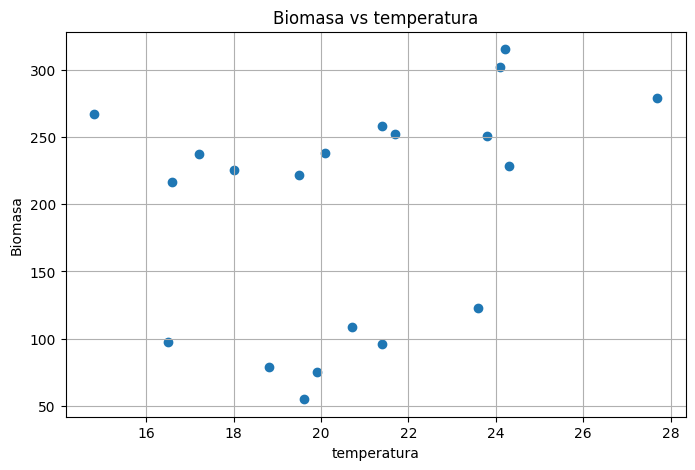

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df_final[variable], df_final["biomasa"])

plt.xlabel(variable)
plt.ylabel("Biomasa")
plt.title(f"Biomasa vs {variable}")

plt.grid(True)

plt.show()

In [42]:
# Resumen estadístico general

resumen = df_final.describe()

resumen

,temperatura,humedad,luz,biomasa
count,20.000000,20.000000,20.000000,20.000000
mean,20.695000,78.090000,901.000000,196.415000
std,3.259234,8.047615,307.177816,84.389369
min,14.800000,63.200000,395.000000,54.800000
25%,18.600000,72.350000,670.250000,105.650000
50%,20.400000,76.250000,893.500000,227.050000
75%,23.650000,82.975000,1048.000000,253.975000
max,27.700000,93.000000,1482.000000,315.600000
